In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

In [2]:
import pandas as pd

df = pd.read_csv("Placement.csv")

print(df.head())
print(df.shape)

   Age  Gender                         Stream  Internships  CGPA  Hostel  \
0   22    Male  Electronics And Communication            1     8       1   
1   21  Female               Computer Science            0     7       1   
2   22  Female         Information Technology            1     6       0   
3   21    Male         Information Technology            0     8       0   
4   22    Male                     Mechanical            0     8       1   

   HistoryOfBacklogs  PlacedOrNot  
0                  1            1  
1                  1            1  
2                  0            1  
3                  1            1  
4                  0            1  
(2966, 8)


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                2966 non-null   int64
 1   Gender             2966 non-null   str  
 2   Stream             2966 non-null   str  
 3   Internships        2966 non-null   int64
 4   CGPA               2966 non-null   int64
 5   Hostel             2966 non-null   int64
 6   HistoryOfBacklogs  2966 non-null   int64
 7   PlacedOrNot        2966 non-null   int64
dtypes: int64(6), str(2)
memory usage: 246.0 KB
None


In [4]:
print(df.isnull().sum())

Age                  0
Gender               0
Stream               0
Internships          0
CGPA                 0
Hostel               0
HistoryOfBacklogs    0
PlacedOrNot          0
dtype: int64


In [5]:
print(f"Shape of Dataframe is: {df.shape}")

Shape of Dataframe is: (2966, 8)


In [6]:
print('Datatype in Each Column\n')
pd.DataFrame(df.dtypes, columns=['Datatype']).rename_axis("Column Name")

Datatype in Each Column



,Datatype
Column Name,
Age,int64
Gender,str
Stream,str
Internships,int64
CGPA,int64
Hostel,int64
HistoryOfBacklogs,int64
PlacedOrNot,int64


In [7]:
df.describe().T.style.bar(subset=['mean'], color='#205ff2').background_gradient(subset=['std'], cmap='Reds').background_gradient(subset=['50%'], cmap='coolwarm')

,count,mean,std,min,25%,50%,75%,max
Age,2966.000000,21.485840,1.324933,19.000000,21.000000,21.000000,22.000000,30.000000
Internships,2966.000000,0.703641,0.740197,0.000000,0.000000,1.000000,1.000000,3.000000
CGPA,2966.000000,7.073837,0.967748,5.000000,6.000000,7.000000,8.000000,9.000000
Hostel,2966.000000,0.269049,0.443540,0.000000,0.000000,0.000000,1.000000,1.000000
HistoryOfBacklogs,2966.000000,0.192178,0.394079,0.000000,0.000000,0.000000,0.000000,1.000000
PlacedOrNot,2966.000000,0.552596,0.497310,0.000000,0.000000,1.000000,1.000000,1.000000


In [8]:
pd.DataFrame(df.isnull().sum(), columns=["Null Values"]).rename_axis("Column Name")

,Null Values
Column Name,
Age,0
Gender,0
Stream,0
Internships,0
CGPA,0
Hostel,0
HistoryOfBacklogs,0
PlacedOrNot,0


# Fortunately data has no missing value

In [9]:
pd.DataFrame(df.isnull().sum(), columns=["Null Values"]).rename_axis("Column Name")

,Null Values
Column Name,
Age,0
Gender,0
Stream,0
Internships,0
CGPA,0
Hostel,0
HistoryOfBacklogs,0
PlacedOrNot,0


In [10]:
import plotly.express as px

In [11]:
fig = px.histogram(df, 'Age',
                   color="Gender",
                   marginal='violin',
                   title="<b>Average Age Gender wise</b>")

fig.update_traces(marker={"opacity": 0.7})

fig.add_vline(x=df['Age'].mean(),
              line_width=2,
              line_dash="dash",
              line_color="black")

fig.show()

In [12]:
px.histogram(df,
             x="Gender",
             title="<b>Total Male and Female</b>",
             color="Gender")

In [13]:
fig = px.pie(df, names = "Gender",
             title = "<b>Counts in Gender</b>",
             hole = 0.5, template = "plotly_dark")

fig.update_traces(textposition='inside',
                  textinfo='percent+label',
                  marker=dict(line=dict(color='#000000', width = 1.5)))


fig.show()

In [14]:
male = df[df['Gender'] == "Male"]
female = df[df['Gender'] == "Female"]

In [15]:
total_male = male.shape[0]
total_female = female.shape[0]

In [16]:
total_male_pass = male[male['PlacedOrNot'] == 1].shape[0]
total_female_pass = female[female['PlacedOrNot'] == 1].shape[0]

In [17]:
import numpy as np

In [18]:
pass_male_percentage = np.round((total_male_pass * 100) / total_male, 2)
pass_female_percentage = np.round((total_female_pass * 100) / total_female, 2)

print("Male Pass %:", pass_male_percentage)
print("Female Pass %:", pass_female_percentage)

Male Pass %: 55.11
Female Pass %: 56.01


In [19]:
details = {"Total Male": [total_male],
             "Total Female": [total_female],
             "Total male pass" : [total_male_pass],
             "Total female pass" : [total_female_pass],
             "% of Passed Male" : [pass_male_percentage],
             "% of Passed Female" : [pass_female_percentage]}

In [20]:
details

{'Total Male': [2475],
 'Total Female': [491],
 'Total male pass': [1364],
 'Total female pass': [275],
 '% of Passed Male': [np.float64(55.11)],
 '% of Passed Female': [np.float64(56.01)]}

In [21]:
gender_wise = pd.DataFrame(details, index=["Detail"])
gender_wise.T

,Detail
Total Male,2475.00
Total Female,491.00
Total male pass,1364.00
Total female pass,275.00
% of Passed Male,55.11
% of Passed Female,56.01


In [22]:
fig = px.histogram(
    data_frame=df,
    x="Stream",
    color="PlacedOrNot",
    title="<b>Counts of Stream</b>",
    pattern_shape_sequence=['x'],
    template='plotly_dark'
)

fig.update_layout(
    title_x=0.5,
    title_font=dict(size=20),
    uniformtext_minsize=15
)

fig.show()

# Majority of candidate are Computer Science Student and they are also large in number who got placement as compare to other Streams

# Displaying all those records whose CGPA is above average

In [23]:
cgpa_above_avg = df[df['CGPA'] > df['CGPA'].mean()]

cgpa_above_avg

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8,1,1,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1
11,22,Female,Electrical,1,8,0,1,1
13,21,Male,Computer Science,1,8,0,1,1
...,...,...,...,...,...,...,...,...
2951,21,Male,Computer Science,3,8,0,0,1
2952,23,Male,Mechanical,0,8,1,0,1
2954,23,Female,Computer Science,1,8,0,1,1
2956,22,Male,Computer Science,0,8,0,0,1


In [24]:
fig = px.histogram(data_frame = cgpa_above_avg,
                   x = 'CGPA',
                   color='PlacedOrNot',
                   title = "<b>Above Average CGPA Vs Placement</b>",
                   template='plotly')

fig.update_layout(bargap=0.2)

fig.show()

# Above graph represents that all those students whose CGPA is above average has successfully pass placement test, So we can say that if a person has higher CGPA it will increase his/her chance of placement.

# Candidates whose CGPA is below average

In [25]:
cgpa_below_avg = df[df['CGPA'] < df['CGPA'].mean()]

cgpa_below_avg

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
1,21,Female,Computer Science,0,7,1,1,1
2,22,Female,Information Technology,1,6,0,0,1
5,22,Male,Electronics And Communication,0,6,0,0,0
6,21,Male,Computer Science,0,7,0,1,0
7,21,Male,Information Technology,1,7,0,0,0
...,...,...,...,...,...,...,...,...
2960,23,Male,Mechanical,1,7,1,0,0
2961,23,Male,Information Technology,0,7,0,0,0
2962,23,Male,Mechanical,1,7,1,0,0
2963,22,Male,Information Technology,1,7,0,0,0


In [26]:
fig = px.histogram(data_frame = cgpa_below_avg,
                   x = 'CGPA',
                   color='PlacedOrNot',
                   title = "<b>Below Average CGPA Vs Placement</b>",
                   template='plotly_dark', barmode='group')

fig.update_layout(bargap=0.2)

fig.show()

# From above above, if some student has CGPA below average it will reduce his/her chances of placement

In [27]:
stream_wise = df.groupby('Stream').agg({'Age':'mean',
                                          'Internships' : 'sum',                            
                                           "CGPA":'mean',
                                           'PlacedOrNot':'sum'})

stream_wise.style.highlight_max()

,Age,Internships,CGPA,PlacedOrNot
Stream,,,,
Civil,21.441640,173,7.094637,146
Computer Science,21.559278,676,7.039948,452
Electrical,21.299401,203,7.080838,181
Electronics And Communication,21.410377,306,7.125000,251
Information Technology,21.539797,509,7.073806,409
Mechanical,21.518868,220,7.063679,200


In [28]:
px.bar(data_frame=stream_wise, barmode='group',
       title = "<b>Stream wise Analyzing</b>",template="plotly_dark")

# From Computer Science degree most of the student placed...


In [29]:
no_internship = df[df['Internships'] == 0]

no_internship

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
1,21,Female,Computer Science,0,7,1,1,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1
5,22,Male,Electronics And Communication,0,6,0,0,0
6,21,Male,Computer Science,0,7,0,1,0
...,...,...,...,...,...,...,...,...
2956,22,Male,Computer Science,0,8,0,0,1
2958,23,Male,Computer Science,0,6,0,1,0
2959,23,Male,Information Technology,0,7,0,0,0
2961,23,Male,Information Technology,0,7,0,0,0


In [30]:
fig = px.histogram(data_frame = no_internship,
                   x = "PlacedOrNot",
                   color="PlacedOrNot",
                   title = "<b>No Internship Experience Vs Placement</b>",
                   template = 'plotly_dark')

fig.update_layout(bargap = 0.2)

fig.show()

Encoding starts

In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
le_gender = LabelEncoder()
le_stream = LabelEncoder()

In [33]:
df["Gender"] = le_gender.fit_transform(df["Gender"])
df["Stream"] = le_stream.fit_transform(df["Stream"])

In [34]:
df.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,1,3,1,8,1,1,1
1,21,0,1,0,7,1,1,1
2,22,0,4,1,6,0,0,1
3,21,1,4,0,8,0,1,1
4,22,1,5,0,8,1,0,1


In [35]:
X = df.drop("PlacedOrNot", axis=1)
y = df["PlacedOrNot"]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [37]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8737373737373737


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

TypeError: missing a required argument: 'y_pred'

In [ ]:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[256  24]
 [ 51 263]]


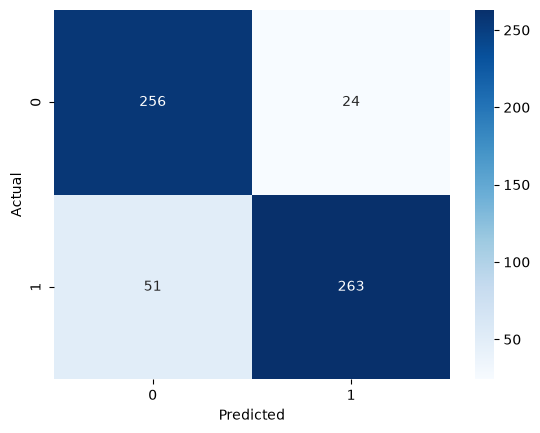

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

             Feature  Importance
4               CGPA    0.652121
0                Age    0.122779
2             Stream    0.089644
3        Internships    0.089451
6  HistoryOfBacklogs    0.020168
1             Gender    0.013598
5             Hostel    0.012239


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("Placement.csv")

In [ ]:
df.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot
0,22,Male,Electronics And Communication,1,8,1,1,1
1,21,Female,Computer Science,0,7,1,1,1
2,22,Female,Information Technology,1,6,0,0,1
3,21,Male,Information Technology,0,8,0,1,1
4,22,Male,Mechanical,0,8,1,0,1


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_stream = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])
df["Stream"] = le_stream.fit_transform(df["Stream"])

In [ ]:
X = df.drop("PlacedOrNot", axis=1)
y = df["PlacedOrNot"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
import joblib

joblib.dump(model, "placement_model.pkl")
print("Model saved successfully")

Model saved successfully


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8737373737373737


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       280
           1       0.92      0.84      0.88       314

    accuracy                           0.87       594
   macro avg       0.88      0.88      0.87       594
weighted avg       0.88      0.87      0.87       594



In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87       280
           1       0.92      0.84      0.88       314

    accuracy                           0.87       594
   macro avg       0.88      0.88      0.87       594
weighted avg       0.88      0.87      0.87       594



In [ ]:
pred = model.predict(X_test)

print(pred[:10])

[0 1 1 0 0 1 0 0 1 0]


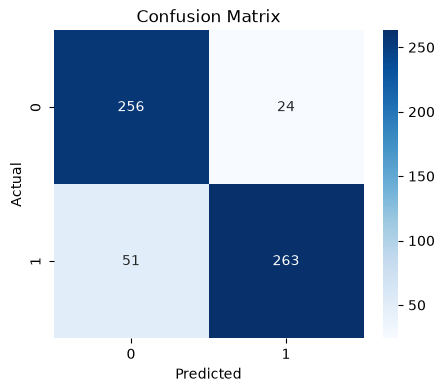

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88       280
           1       0.92      0.84      0.88       314

    accuracy                           0.88       594
   macro avg       0.88      0.88      0.88       594
weighted avg       0.88      0.88      0.88       594



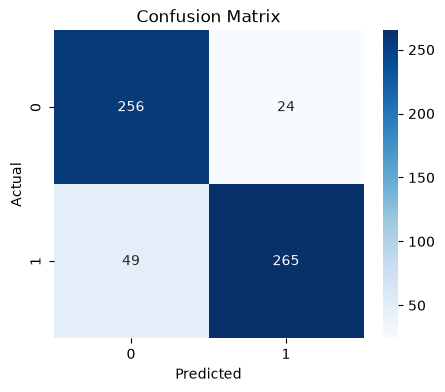

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:

import os

print(os.listdir())

['.vscode', 'app.py', 'Placement.csv', 'placement.ipynb', 'placement_model.pkl', 'requirements.txt', 'venv']


In [ ]:
import os

print(os.path.exists("placement_model.pkl"))

True


In [ ]:
import joblib

model = joblib.load("placement_model.pkl")

# So from above graph, if person don't have any Internship Experience, it will not much effect on his/her placement. Majority of the student who don't have any Internship Experience has passed the placement exam

In [ ]:
dummy_gender = pd.get_dummies(df['Gender'])
dummy_stream = pd.get_dummies(df['Stream'])

In [ ]:
data = pd.concat([df.drop(["Gender", "Stream"], axis = 1), dummy_gender, dummy_stream], axis = 1)

data

,Age,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot,0,1,0,1,2,3,4,5
0,22,1,8,1,1,1,False,True,False,False,False,True,False,False
1,21,0,7,1,1,1,True,False,False,True,False,False,False,False
2,22,1,6,0,0,1,True,False,False,False,False,False,True,False
3,21,0,8,0,1,1,False,True,False,False,False,False,True,False
4,22,0,8,1,0,1,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2961,23,0,7,0,0,0,False,True,False,False,False,False,True,False
2962,23,1,7,1,0,0,False,True,False,False,False,False,False,True
2963,22,1,7,0,0,0,False,True,False,False,False,False,True,False
2964,22,1,7,0,0,0,False,True,False,True,False,False,False,False


In [ ]:
print(data.columns.tolist())

['Age', 'Internships', 'CGPA', 'Hostel', 'HistoryOfBacklogs', 'PlacedOrNot', 0, 1, 0, 1, 2, 3, 4, 5]


In [ ]:
data.head()

,Age,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot,0,1,0,1,2,3,4,5
0,22,1,8,1,1,1,False,True,False,False,False,True,False,False
1,21,0,7,1,1,1,True,False,False,True,False,False,False,False
2,22,1,6,0,0,1,True,False,False,False,False,False,True,False
3,21,0,8,0,1,1,False,True,False,False,False,False,True,False
4,22,0,8,1,0,1,False,True,False,False,False,False,False,True


In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                2966 non-null   int64
 1   Internships        2966 non-null   int64
 2   CGPA               2966 non-null   int64
 3   Hostel             2966 non-null   int64
 4   HistoryOfBacklogs  2966 non-null   int64
 5   PlacedOrNot        2966 non-null   int64
 6   0                  2966 non-null   bool 
 7   1                  2966 non-null   bool 
 8   0                  2966 non-null   bool 
 9   1                  2966 non-null   bool 
 10  2                  2966 non-null   bool 
 11  3                  2966 non-null   bool 
 12  4                  2966 non-null   bool 
 13  5                  2966 non-null   bool 
dtypes: bool(8), int64(6)
memory usage: 162.3 KB


In [ ]:
#data = data[['Age', 'Male', 'Female',
#             'Electronics And Communication',
#             'Computer Science', 'Information Technology',
#             'Mechanical', 'Electrical', "Civil",
#             "Internships","CGPA",'Hostel',
#             'HistoryOfBacklogs', 'PlacedOrNot']]



In [ ]:
scaler = StandardScaler()
scaler.fit(df.drop('PlacedOrNot',axis=1))
scaled_features = scaler.transform(df.drop('PlacedOrNot',axis=1))

In [ ]:
scaled_features = pd.DataFrame(scaled_features, columns = data.columns[:-1])
scaled_features.head()

ValueError: Shape of passed values is (2966, 7), indices imply (2966, 13)

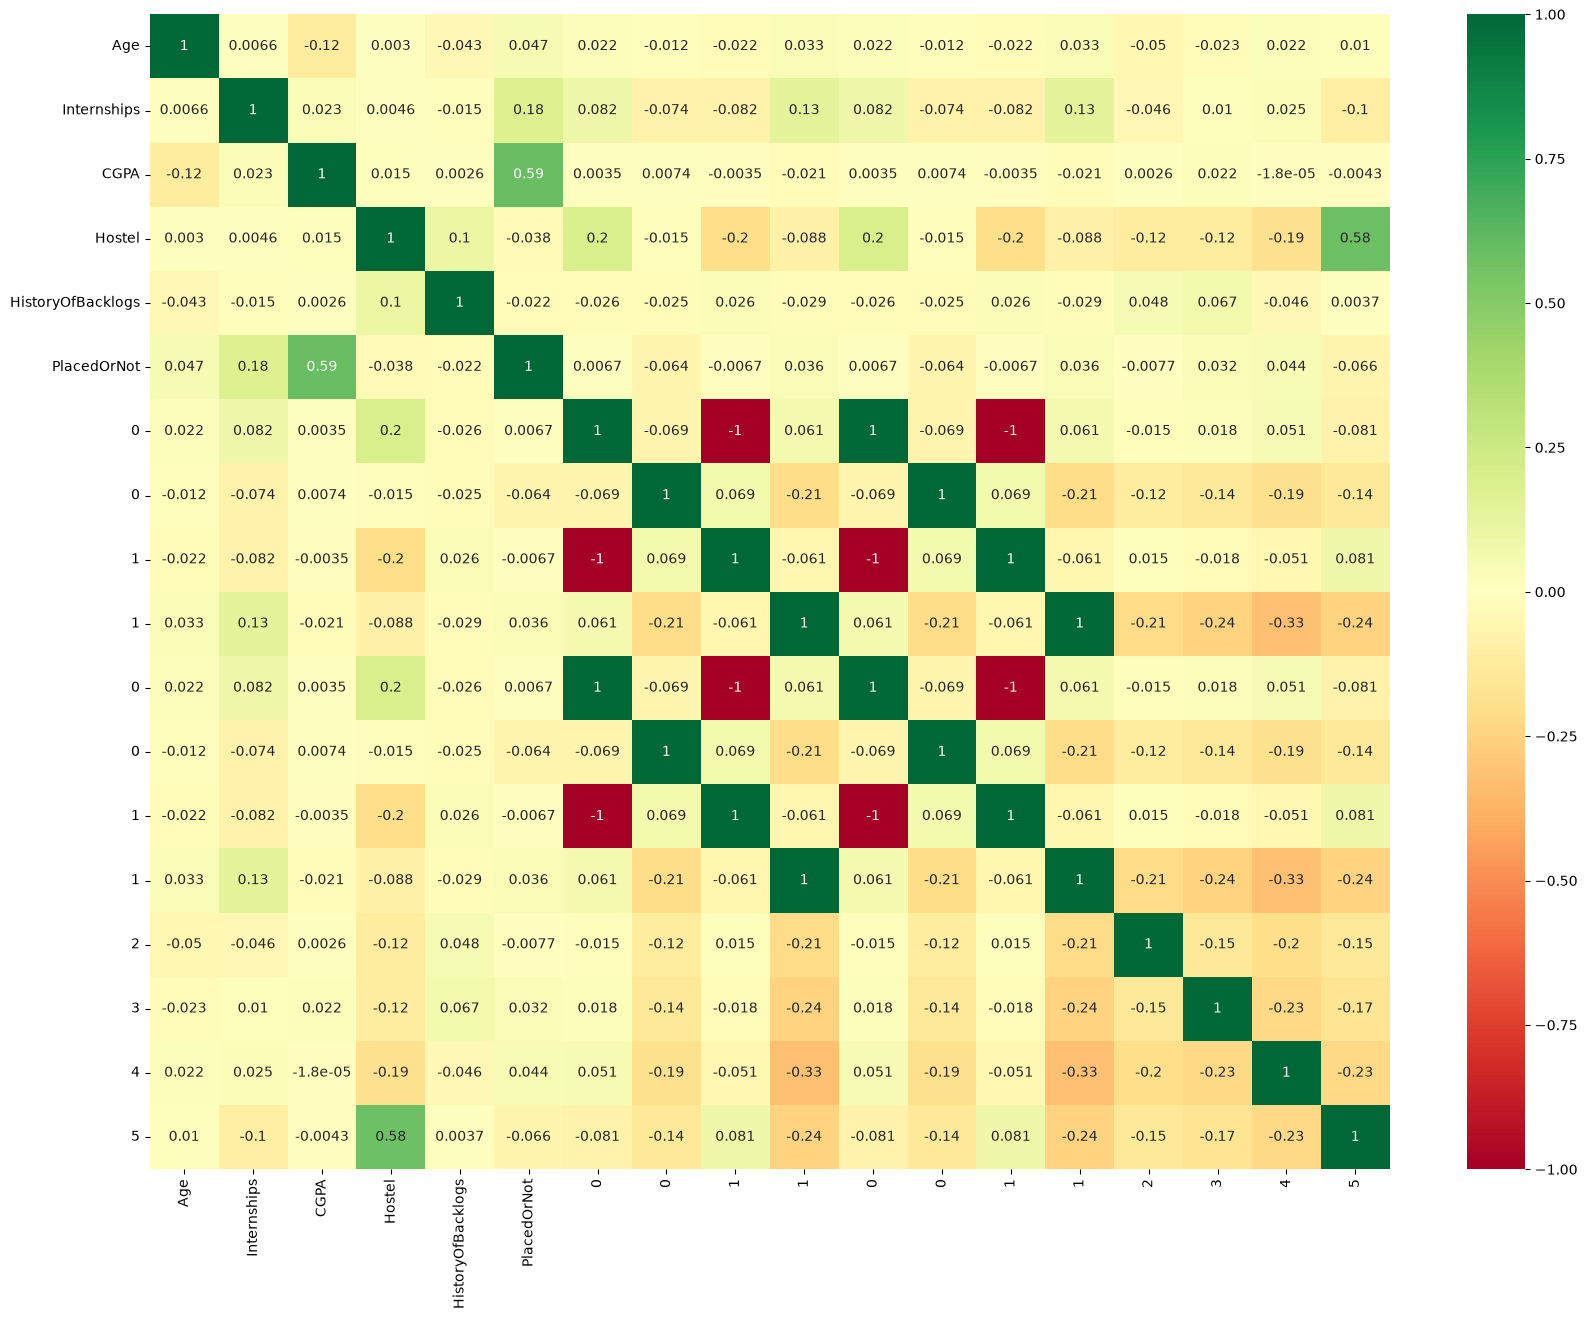

In [ ]:
corrmat = data.corr()
top_corr_features = corrmat.index

plt.figure(figsize=(20,15))

#plot heat map
g = sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

# Internship and CGPA is highly coorelated with dependent feature i.e PlacedOrNot

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(scaled_features,
                                                    data['PlacedOrNot'],
                                                    test_size = 0.25,
                                                    random_state = 0)

In [ ]:
print(f"Shape of X_train is: {X_train.shape}")
print(f"Shape of X_test is: {X_test.shape}\n")

print(f"Shape of y_train is: {y_train.shape}")
print(f"Shape of y_test is: {y_test.shape}")

Shape of X_train is: (2224, 7)
Shape of X_test is: (742, 7)

Shape of y_train is: (2224,)
Shape of y_test is: (742,)


In [ ]:
def models_score(models, X_train, X_test, y_train, y_test):    
    
    scores = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        scores[name] = model.score(X_test,y_test)

    model_scores = pd.DataFrame(scores, index=['Score']).transpose()
    model_scores = model_scores.sort_values('Score')
        
    return model_scores

In [ ]:
models = {
    "RandomForest": RandomForestClassifier(),
    "KNeighborsClassifier": KNeighborsClassifier()
}

In [ ]:
model_scores = models_score(models, X_train, X_test, y_train, y_test)

In [ ]:
model_scores.style.highlight_max()

,Score
KNeighborsClassifier,0.843666
RandomForest,0.874663
XgBoost,0.876011


In [ ]:
model_scores = model_scores.reset_index().rename({"index":"Algorithms"}, axis = 1)

In [ ]:
model_scores.style.bar(color = '#47b7ed')

,Algorithms,Score
0,KNeighborsClassifier,0.843666
1,RandomForest,0.874663
2,XgBoost,0.876011


In [ ]:
label = model_scores['Algorithms']
value = model_scores['Score']

fig = go.Figure(data = [go.Pie(labels = label, values = value, rotation = 90)]) # pyright: ignore[reportUndefinedVariable]

fig.update_traces(textposition = 'inside',
                  textinfo = 'percent+label',
                  marker = dict(line = dict(color='#000000', width = 1.5)))

fig.update_layout(title = "<b>Models Score</b>",
                  template = 'plotly_dark')

fig.show()

In [ ]:
## Hyper Parameter Optimization

params={
 "learning_rate"    : [0.05, 0.10, 0.15, 0.20, 0.25, 0.30 ] ,
 "max_depth"        : [ 3, 4, 5, 6, 8, 10, 12, 15],
 "min_child_weight" : [ 1, 3, 5, 7 ],
 "gamma"            : [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
 "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7 ]
    
}

In [ ]:
import datetime


def timer(start_time=None):
    if not start_time:
        start_time = datetime.now()
        return start_time
    elif start_time:
        thour, temp_sec = divmod((datetime.now() - start_time).total_seconds(), 3600)
        tmin, tsec = divmod(temp_sec, 60)
        print(f'\nTime taken: {thour} hours {tmin} minutes and {round(tsec, 2)} seconds.')

In [ ]:
from xgboost import XGBClassifier # type: ignore

# For now I use xgboost algo
xgb_classifier = XGBClassifier()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV


random_search = RandomizedSearchCV(xgb_classifier,
                                   param_distributions=params,
                                   n_iter=5,
                                   scoring='roc_auc',
                                   n_jobs=-1,
                                   cv=5, verbose=3)

In [ ]:
start_time = timer(None) 

random_search.fit(X_train, y_train)

timer(start_time)

NameError: name 'timer' is not defined

In [ ]:
xgb_best_params = random_search.best_estimator_

In [ ]:
random_search.best_params_

{'min_child_weight': 5,
 'max_depth': 8,
 'learning_rate': 0.1,
 'gamma': 0.0,
 'colsample_bytree': 0.7}

In [ ]:
classifier = xgb_best_params

In [ ]:
classifier.fit(X_train, y_train, eval_metric='logloss')

/opt/conda/lib/python3.7/site-packages/xgboost/sklearn.py:797: UserWarning:

`eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.



XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.7,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, gamma=0.0, gpu_id=-1, grow_policy='depthwise',
              importance_type=None, interaction_constraints='',
              learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
              max_delta_step=0, max_depth=8, max_leaves=0, min_child_weight=5,
              missing=nan, monotone_constraints='()', n_estimators=100,
              n_jobs=0, num_parallel_tree=1, predictor='auto', random_state=0,
              reg_alpha=0, reg_lambda=1, ...)

In [ ]:
pred = classifier.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred)}")

Accuracy: 0.8975741239892183


In [ ]:
print(y_test[:5])

2395    0
794     1
1894    1
332     0
2023    0
Name: PlacedOrNot, dtype: int64


In [ ]:
dir()

['DecisionTreeClassifier',
 'In',
 'KNeighborsClassifier',
 'LabelEncoder',
 'Out',
 'RandomForestClassifier',
 'StandardScaler',
 'X',
 'X_test',
 'X_train',
 '_',
 '_10',
 '_11',
 '_14',
 '_22',
 '_23',
 '_25',
 '_27',
 '_29',
 '_30',
 '_31',
 '_36',
 '_39',
 '_8',
 '_9',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i44',
 '_i45',
 '_i46',
 '_i47',
 '_i48',
 '_i49',
 '_i5',
 '_i50',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'accuracy_score',
 'cgpa_above_avg',
 'cgpa_below_avg',
 'classification_report',
 'confusion_m

# Ploting confusion matrix

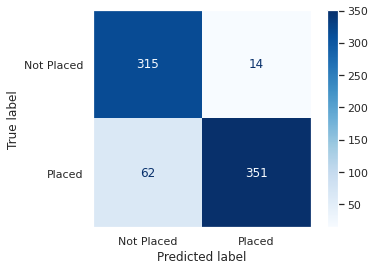

In [ ]:
plot_confusion_matrix(classifier, # pyright: ignore[reportUndefinedVariable]
                      X_test, y_test,
                      cmap = plt.cm.Blues,
                      display_labels = ['Not Placed', 'Placed'])
plt.grid(False)
plt.show();